# Implicit function theorem vs. the HoDEL adjoint ODE

HoDEL (*Homotopy-Based Differentiable Energy Learning*, Jawed et al.) learns an energy $E(x;\Theta)$ from observed equilibria. It does this by viewing the equilibrium path as an ODE in the homotopy parameter $\lambda$ and back-propagating with an **adjoint ODE** (Eqs. 6, 15, 18, 24 and Theorem 3 of the paper).

`dismech-jax` instead differentiates every equilibrium solve with the **implicit function theorem** (IFT): `System.solve` wraps Newton in `jax.lax.custom_root`, so a plain `jax.grad` through `rod.solve` gives the IFT gradient.

This notebook

1. proves that the two gradients are **equal** (Section 0),
2. checks this numerically and measures the cost of each on **CPU** (Sections 2 and 3),
3. runs an **ablation** on an inverse problem that learns a neural bending law from observed equilibria, using IFT, the exact adjoint ODE, and the paper's frozen-costate formula (Section 4).

## 0. Derivation: the adjoint ODE is the IFT in disguise

**Setup.** Free DOFs $x\in\mathbb R^n$, fixed DOFs prescribed along the homotopy $z=z(\lambda)$, $\lambda\in[0,1]$, energy $E(x,z;\Theta)$. Write

$$g(x,\lambda;\Theta)=\nabla_xE\big(x,z(\lambda);\Theta\big)\;(\texttt{rod.residual}),\qquad H=\partial_xg=\nabla^2_{xx}E,\qquad g_\lambda=\partial_\lambda g=\nabla^2_{xz}E\,z'(\lambda),\qquad g_\Theta=\partial_\Theta g .$$

The equilibrium path $x(\lambda;\Theta)$ satisfies $g=0$ and starts at the stress-free rest state $x(0)=x_0$, with $g(x_0,0;\Theta)=0$ for **every** $\Theta$. We observe the equilibria at $0<\lambda_1<\dots<\lambda_N=1$ and use the loss $\mathcal L=\sum_i\ell_i\big(x(\lambda_i)\big)$. The single-point loss of Eq. 3 is the case $N=1$. $H$ is symmetric and invertible on the path.

---

**(A) IFT** (`jax.grad` through `rod.solve`). Differentiate $g(x(\lambda_i;\Theta),\lambda_i;\Theta)=0$ with respect to $\Theta$ to get $H_is_i+g_{\Theta,i}=0$ for $s_i=\partial x(\lambda_i)/\partial\Theta$. Therefore

$$\boxed{\frac{d\mathcal L}{d\Theta}\Big|_\text{IFT}=-\sum_i\mu_i^\top g_{\Theta,i},\qquad H_i\mu_i=\nabla\ell_i}$$

This needs one linear solve per observation, and nothing in between.

**(B) Adjoint ODE** (HoDEL). Differentiating $g=0$ along $\lambda$ gives the homotopy ODE (Eq. 6/15)

$$\frac{dx}{d\lambda}=f(x,\lambda;\Theta):=-H^{-1}g_\lambda .$$

Treat it as a neural ODE with the continuous adjoint (Theorem 3; Chen et al. 2018). Integrate backward

$$\frac{da}{d\lambda}=-f_x^\top a,\qquad a(1)=\nabla\ell_N,\qquad a(\lambda_i^-)=a(\lambda_i^+)+\nabla\ell_i ,$$

$$\boxed{\frac{d\mathcal L}{d\Theta}\Big|_\text{ODE}=a(0)^\top s(0)+\int_0^1a^\top f_\Theta\,d\lambda}$$

---

**Lemma 1 (the residual is conserved).** Along any ODE solution let $G(\lambda)=g(x(\lambda),\lambda;\Theta)$. Then $G'=Hf+g_\lambda=0$, so $G(\lambda)=G(0)=0$. The ODE solution *is* the equilibrium path, which is why the forward pass may use Newton (`rod.solve`) instead of time stepping.

**Lemma 2 (the propagator is a Hessian ratio).** Lemma 1 holds for every initial condition, so $\partial G/\partial x(\lambda')$ is also constant in $\lambda$. This gives $H(\lambda)\Phi(\lambda,\lambda')=H(\lambda')$ for the state transition matrix of $\dot{\delta x}=f_x\delta x$, i.e. $\Phi(\lambda,\lambda')=H(\lambda)^{-1}H(\lambda')$. On each interval the adjoint is $a(\lambda)^\top=a(\lambda_i^-)^\top\Phi(\lambda_i,\lambda)$. By induction from $a(1)=\nabla\ell_N=H_N\mu_N$,

$$\boxed{a(\lambda)=H(\lambda)\,M(\lambda),\qquad M(\lambda)=\sum_{\lambda_i>\lambda}\mu_i}$$

The HoDEL adjoint is the sum of the IFT multipliers of all later observations, multiplied by the *current* Hessian. In exact arithmetic it is bounded ($\|a\|\le\|H\|\,\|M\|$), so it does not blow up exponentially.

**Lemma 3 (the parameter forcing is a total derivative).** Differentiate $Hf=-g_\lambda$ with respect to $\Theta$ at fixed $(x,\lambda)$ to get $Hf_\Theta=-\partial_\Theta g_\lambda-(\partial_\Theta H)f$. Along the path, by the symmetry of mixed partials, $\frac{d}{d\lambda}g_\Theta=(\partial_xg_\Theta)f+\partial_\lambda g_\Theta=(\partial_\Theta H)f+\partial_\Theta g_\lambda$. Hence

$$Hf_\Theta=-\frac{d}{d\lambda}g_\Theta\big(x(\lambda),\lambda;\Theta\big).$$

**Theorem.** Combine the lemmas. $M$ is piecewise constant, so

$$\int_0^1a^\top f_\Theta\,d\lambda=\int_0^1M^\top Hf_\Theta\,d\lambda=-\sum_i\mu_i^\top\big(g_{\Theta,i}-g_{\Theta}(\lambda{=}0)\big).$$

Since $g(x_0,0;\Theta)=0$ for all $\Theta$, we have $g_\Theta(0)=0$ and $s(0)=0$. (If instead $x_0(\Theta)$ is the $\Theta$-dependent rest equilibrium, the boundary term $a(0)^\top s(0)=-M(0)^\top g_\Theta(0)$ cancels the same term.) Therefore

$$\frac{d\mathcal L}{d\Theta}\Big|_\text{ODE}=-\sum_i\mu_i^\top g_{\Theta,i}=\frac{d\mathcal L}{d\Theta}\Big|_\text{IFT}.\qquad\blacksquare$$

The adjoint ODE "integrates up" to a quantity that the IFT evaluates directly at the observed points. The whole $\lambda$ integral telescopes.

---

**Remarks used in the experiments**

* **When they differ.** The proof needs the ODE to start on the equilibrium manifold *for the current* $\Theta$. A neural-ODE fit from a fixed data state $x(t_0)$ (the paper's note on initial values) has $G(0)\ne0$, and the two gradients no longer agree.
* **HoDEL as implemented (Eq. 18/24, pp. 16–18).** It evaluates $\partial_\Theta f$ at detached states and contracts it with the frozen costate $A(\lambda)=\sum_{\lambda_i\ge\lambda}\nabla\ell_i$ instead of $a(\lambda)=H(\lambda)M(\lambda)$. This is exact only if $H$ is constant along each interval. That holds for a quadratic energy, as in the paper's scalar example where $f_x=0$, but it biases the gradient otherwise. Eq. 17 is right only if $d/d\Theta$ is read as the *total* derivative, which includes $f_xs$.
* **Discretization and stiffness (Theorem 3).** The exact $a$ is bounded, but $f_x$ has large eigenvalues of both signs, so an explicit backward integrator needs $\Delta\lambda\,|\mathrm{eig}(f_x)|\lesssim1$ and has $O(\Delta\lambda^p)$ error. The IFT has no discretization error. Its only use for intermediate steps is Newton continuation and path dependence.
* **Cost.** The IFT needs one Hessian factorization per step in the backward pass. The adjoint ODE needs, per step, VJPs of $f=-H^{-1}g_\lambda$, which involve **third derivatives** of $E$ and a solve, several times per step for a 2nd-order scheme.

## 1. Problem: a planar rod with a stiffening bending law

We force CPU before JAX initializes, because the GPU is reserved for another project.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # must be set before importing jax

import time
import equinox as eqx
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from dismech_jax import DER, Geometry, Material, make_rod

jax.config.update("jax_enable_x64", True)
print(jax.devices())

[CpuDevice(id=0)]


A rod of length 1 is clamped at both ends (nodes 0, 1 and the last two nodes). The homotopy moves the left clamp sideways and rotates it, $(p_x,p_y,\phi)=\lambda\,(0,\,0.3,\,1\,\text{rad})$. The fixed DOFs are therefore $z(\lambda)$ and the energy depends on $\lambda$ only through $z$, so $g_\lambda=\nabla^2_{xz}E\,z'(\lambda)$. The path has no compression, so every step is a stable equilibrium (no buckling bifurcation).

**Ground truth.** The in-plane bending density stiffens, $\tfrac12EI\,a^*(\kappa)\kappa^2$ with $a^*(\kappa)=1+(\kappa/\kappa_0)^2$. All other strains (stretch, out-of-plane bending, twist) are the linear `DER` law.

**Model.** The same law with $a_\Theta(\kappa)=\exp\big(\text{MLP}_\Theta(\kappa^2/\kappa_0^2)\big)$, which is positive and even in $\kappa$. It is initialized at $a\equiv1$, i.e. the linear rod. The rest state is stress-free for every $\Theta$, as the derivation requires.

In [2]:
N, L = 21, 1.0
dl = L / (N - 1)
KAPPA0 = 5.0
geom = Geometry(length=L, r0=1e-3, axs=3.14e-8, ixs1=7.85e-13, ixs2=7.85e-11, jxs=1e-10)  # EA=3.1e-3, EI=7.9e-8
mat = Material(density=1200.0, youngs_rod=1e5, poisson_rod=0.3)
K_DER = DER.from_legacy(geom, mat).K


class TrueBending(eqx.Module):
    K: jax.Array

    def __call__(self, s):
        return 0.5 * jnp.sum(self.K * s**2) + 0.5 * self.K[2] * (s[2] / KAPPA0) ** 2 * s[2] ** 2


class NeuralBending(eqx.Module):
    K: jax.Array
    mlp: eqx.nn.MLP

    def a(self, kappa):
        return jnp.exp(self.mlp(jnp.array([(kappa / KAPPA0) ** 2]))[0])

    def __call__(self, s):
        return 0.5 * jnp.sum(self.K * s**2) + 0.5 * self.K[2] * (self.a(s[2]) - 1.0) * s[2] ** 2


left = np.arange(7)
right = np.array([4 * (N - 2) + i for i in range(4)] + [4 * (N - 1) + i for i in range(3)])
fixed = jnp.asarray(np.concatenate([left, right]))
rod_true, aux0 = make_rod(geom, mat, N=N, fixed=fixed, gravity=jnp.zeros(3), model=TrueBending(K_DER))

mlp0 = eqx.nn.MLP(1, 1, 16, 2, activation=jnp.tanh, key=jax.random.PRNGKey(0))
mlp0 = eqx.tree_at(lambda m: (m.layers[-1].weight, m.layers[-1].bias), mlp0,
                   (mlp0.layers[-1].weight * 0.0, jnp.zeros(1)))  # a == 1: linear rod
rod_nn, _ = make_rod(geom, mat, N=N, fixed=fixed, gravity=jnp.zeros(3), model=NeuralBending(K_DER, mlp0))


def with_mlp(mlp):
    return eqx.tree_at(lambda r: r.terms[0].model.mlp, rod_nn, mlp)


zpos = {int(d): i for i, d in enumerate(np.asarray(rod_true.idx_z))}
FINAL = jnp.array([0.0, 0.3, 1.0])  # final (px, py, phi) of the left clamp


def z_of(lam):
    px, py, phi = lam * FINAL
    z = rod_true.z0.at[zpos[0]].set(px).at[zpos[1]].set(py)
    return z.at[zpos[4]].set(px + dl * jnp.cos(phi)).at[zpos[5]].set(py + dl * jnp.sin(phi))


def curvature(q):
    P = jnp.stack([q[0::4], q[1::4]], 1)
    e = P[1:] - P[:-1]
    a, b = e[:-1], e[1:]
    return jnp.arctan2(a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0], jnp.sum(a * b, 1)) / dl


ITERS = 50
OBS = np.array([0.25, 0.5, 0.75, 1.0])  # observed homotopy values


def grid(K):
    # K homotopy steps (K divisible by 4); `obs` indexes into lams, 0 is the rest state
    return jnp.linspace(0.0, 1.0, K + 1), np.rint(OBS * K).astype(int)

**Data.** We solve the true rod on a fine grid and record the free DOFs at $\lambda\in\{0.25,0.5,0.75,1\}$. The loss is the normalized mean squared error over the observations, $\mathcal L=\tfrac12\,\overline{(x_i-x_i^*)^2}/\overline{(x_i^*-x_0)^2}$.

max Newton residual 9.9e-11


max |kappa| in the data 14.9 -> a*(kappa) up to 9.9


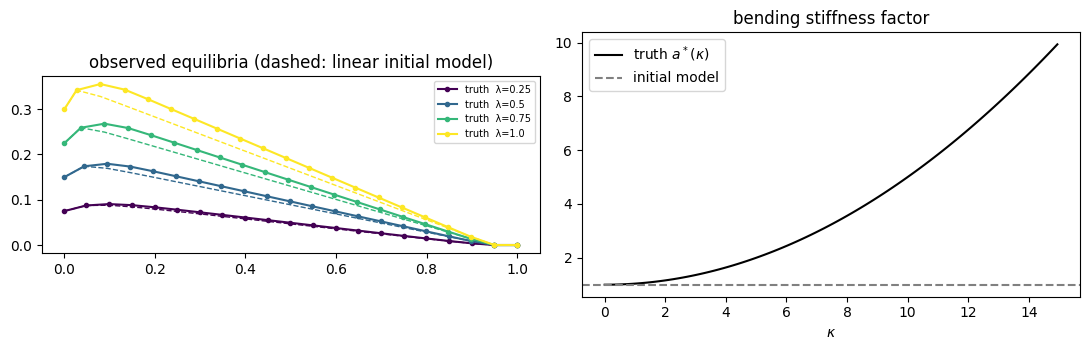

In [3]:
lams_ref, obs_ref = grid(128)
zs_ref = jax.vmap(z_of)(lams_ref)
xs_ref, res_ref = rod_true.solve(zs_ref[1:], aux0, iters=ITERS)
xs_ref = jnp.concatenate([rod_true.x0[None], xs_ref])
X_obs = xs_ref[obs_ref]
scale = jnp.mean((X_obs - rod_true.x0) ** 2)
print(f"max Newton residual {float(res_ref.max()):.1e}")


def obs_loss(X):
    return 0.5 * jnp.mean((X - X_obs) ** 2) / scale


xs_lin, _ = rod_nn.solve(zs_ref[1:], aux0, iters=ITERS)
xs_lin = jnp.concatenate([rod_nn.x0[None], xs_lin])
kmax = max(float(jnp.abs(curvature(rod_true.join(x, z))).max()) for x, z in zip(X_obs, zs_ref[obs_ref]))
print(f"max |kappa| in the data {kmax:.1f} -> a*(kappa) up to {1 + (kmax / KAPPA0) ** 2:.1f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for i, k in enumerate(obs_ref):
    c = plt.cm.viridis(i / 3)
    q = rod_true.join(xs_ref[k], zs_ref[k]); ax[0].plot(q[0::4], q[1::4], ".-", color=c, label=f"truth  λ={OBS[i]}")
    q = rod_nn.join(xs_lin[k], zs_ref[k]); ax[0].plot(q[0::4], q[1::4], "--", color=c, lw=1)
ax[0].set_aspect("equal"); ax[0].set_title("observed equilibria (dashed: linear initial model)"); ax[0].legend(fontsize=7)
kk = np.linspace(0, kmax, 100)
ax[1].plot(kk, 1 + (kk / KAPPA0) ** 2, "k", label=r"truth $a^*(\kappa)$")
ax[1].axhline(1.0, color="gray", ls="--", label="initial model")
ax[1].set_xlabel(r"$\kappa$"); ax[1].set_title("bending stiffness factor"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. The three gradients

* **IFT**: `jax.grad` through `rod.solve`. The `custom_root` already applies $-H^{-1}g_\Theta$ at every step, including the path dependence of the reference frames (`aux`).
* **Adjoint ODE**: the forward pass reuses `rod.solve`, because by Lemma 1 the ODE solution *is* the equilibrium path. It stores the states without a graph. The backward pass integrates $\dot a=-f_x^\top a$ with Heun's method (2nd order, trapezoidal quadrature for $\int a^\top f_\Theta$) and adds the jumps $\nabla\ell_i$ at the observations. Each step uses one linearization of $(\Theta,x)\mapsto f(x,\lambda_k;\Theta)$ and three pullbacks. The frame `aux` is held at its value for that step.
* **HoDEL frozen costate (Eq. 24 as implemented)**: the same quadrature, with $a(\lambda)$ replaced by $A(\lambda)=\sum_{\lambda_i\ge\lambda}\nabla\ell_i$.

In [4]:
def homotopy_velocity(rod, x, lam, aux):
    # f(x, lam; Theta) = -H_xx^{-1} H_xz z'(lam)   (Eq. 6 / 15)
    z, dz = jax.jvp(z_of, (lam,), (jnp.ones_like(lam),))
    H, Hxz = rod.hessian(x, z, aux)
    return -jnp.linalg.solve(H, Hxz @ dz)


# ---- (A) IFT: just jax.grad through the solve --------------------------------
def loss_ift(mlp, lams):
    _, obs = grid(lams.shape[0] - 1)
    xs, _ = with_mlp(mlp).solve(jax.vmap(z_of)(lams[1:]), aux0, iters=ITERS)
    return obs_loss(jnp.concatenate([rod_nn.x0[None], xs])[obs])


ift_value_and_grad = eqx.filter_jit(eqx.filter_value_and_grad(loss_ift))


# ---- (B) adjoint ODE, and (C) HoDEL frozen costate ---------------------------
def forward_states(rod, lams):
    # equilibrium path at every lam_k plus the aux used to solve each step (k=0: rest state)
    zs = jax.vmap(z_of)(lams)
    xs, res = rod.solve(zs[1:], aux0, iters=ITERS)
    xs = jax.lax.stop_gradient(jnp.concatenate([rod.x0[None], xs]))
    _, auxs = jax.lax.scan(lambda a, xz: (rod.update(a, *xz), a), aux0, (xs, zs))
    return xs, jax.lax.stop_gradient(auxs), res


def adjoint_value_and_grad(mlp, lams, frozen=False):
    K = lams.shape[0] - 1
    _, obs = grid(K)
    h = 1.0 / K
    params, static = eqx.partition(mlp, eqx.is_inexact_array)
    rod = with_mlp(mlp)

    xs, auxs, _ = forward_states(rod, lams)
    loss, dldx = jax.value_and_grad(obs_loss)(xs[obs])
    jumps = jnp.zeros_like(xs).at[obs].set(dldx)  # grad l_i at lam_i

    def pullback(k):
        # cotangent a -> (a^T f_Theta, f_x^T a) at (x_k, lam_k)
        aux_k = jax.tree.map(lambda v: v[k], auxs)
        f_k = lambda p, x: homotopy_velocity(with_mlp(eqx.combine(p, static)), x, lams[k], aux_k)
        return jax.vjp(f_k, params, xs[k])[1]

    add = lambda u, v, c=1.0: jax.tree.map(lambda p, q: p + c * q, u, v)

    def step(carry, k):
        a, ga, Ja, G = carry  # a = a(lam_k^-), (ga, Ja) = pullback_k(a), G = int_{lam_k}^1 a^T f_Theta
        pb = pullback(k - 1)
        if frozen:
            a_new = a
            g_new, J_new = pb(a_new)
        else:
            _, J_pred = pb(a + h * Ja)  # backward in lam: a(lam - h) = a + h f_x^T a
            a_new = a + 0.5 * h * (Ja + J_pred)
            g_new, J_new = pb(a_new)
        G = add(G, add(ga, g_new), 0.5 * h)
        g_jump, J_jump = pb(jumps[k - 1])
        return (a_new + jumps[k - 1], add(g_new, g_jump), J_new + J_jump, G), a_new

    aK = jumps[K]
    gK, JK = pullback(K)(aK)
    G0 = jax.tree.map(jnp.zeros_like, params)
    (_, _, _, G), a_path = jax.lax.scan(step, (aK, gK, JK, G0), jnp.arange(K, 0, -1))
    # a(0)^T s(0) = 0: the rest state does not depend on Theta
    return loss, G, a_path[::-1]  # a_path[k] = a(lam_k^+), k = 0..K-1


adjoint_ode = eqx.filter_jit(lambda mlp, lams: adjoint_value_and_grad(mlp, lams)[:2])
hodel_frozen = eqx.filter_jit(lambda mlp, lams: adjoint_value_and_grad(mlp, lams, frozen=True)[:2])

### 2a. Gradient agreement

We evaluate all three at a non-trivial $\Theta$: the linear initial model, with random weights added to the last layer so that $a_\Theta\ne1$. The IFT gradient is also checked against a central finite difference along a random direction.

In [5]:
def flat(tree):
    return jnp.concatenate([v.ravel() for v in jax.tree.leaves(eqx.filter(tree, eqx.is_inexact_array))])


mlp_test = eqx.tree_at(lambda m: m.layers[-1].weight, mlp0,
                       0.3 * jax.random.normal(jax.random.PRNGKey(1), mlp0.layers[-1].weight.shape))
lams64, _ = grid(64)

l_ift, g_ift = ift_value_and_grad(mlp_test, lams64)
g_ift = flat(g_ift)

# finite-difference check of the IFT gradient along a random direction
p, st = eqx.partition(mlp_test, eqx.is_inexact_array)
leaves, tdef = jax.tree.flatten(p)
dirs = [jax.random.normal(k, v.shape) for k, v in zip(jax.random.split(jax.random.PRNGKey(2), len(leaves)), leaves)]
d = jax.tree.unflatten(tdef, dirs)
eps = 1e-5
shift = lambda c: eqx.combine(jax.tree.map(lambda u, v: u + c * v, p, d), st)
fd = (loss_ift(shift(eps), lams64) - loss_ift(shift(-eps), lams64)) / (2 * eps)
print(f"IFT directional derivative {float(g_ift @ flat(d)):.6e}   finite difference {float(fd):.6e}")

rows = []
for K in [8, 16, 32, 64, 128, 256]:
    lams, _ = grid(K)
    l_ode, g_ode = adjoint_ode(mlp_test, lams)
    _, g_frz = hodel_frozen(mlp_test, lams)
    e_ode = float(jnp.linalg.norm(flat(g_ode) - g_ift) / jnp.linalg.norm(g_ift))
    e_frz = float(jnp.linalg.norm(flat(g_frz) - g_ift) / jnp.linalg.norm(g_ift))
    cos = float(flat(g_frz) @ g_ift / jnp.linalg.norm(flat(g_frz)) / jnp.linalg.norm(g_ift))
    rows.append((K, e_ode, e_frz, cos))
    print(f"K={K:4d}  |loss_ODE - loss_IFT| = {abs(float(l_ode - l_ift)):.1e}   "
          f"rel. error adjoint ODE {e_ode:.2e}   rel. error HoDEL frozen {e_frz:.2e} (cosine {cos:+.3f})")
rows = np.array(rows)

IFT directional derivative 7.463682e-03   finite difference 7.463839e-03


K=   8  |loss_ODE - loss_IFT| = 7.0e-11   rel. error adjoint ODE 6.66e-02   rel. error HoDEL frozen 1.68e+00 (cosine +0.908)


K=  16  |loss_ODE - loss_IFT| = 2.0e-10   rel. error adjoint ODE 1.50e-02   rel. error HoDEL frozen 1.54e+00 (cosine +0.926)


K=  32  |loss_ODE - loss_IFT| = 4.7e-11   rel. error adjoint ODE 2.94e-03   rel. error HoDEL frozen 1.56e+00 (cosine +0.924)


K=  64  |loss_ODE - loss_IFT| = 0.0e+00   rel. error adjoint ODE 8.43e-04   rel. error HoDEL frozen 1.56e+00 (cosine +0.923)


K= 128  |loss_ODE - loss_IFT| = 6.7e-10   rel. error adjoint ODE 2.45e-04   rel. error HoDEL frozen 1.56e+00 (cosine +0.923)


K= 256  |loss_ODE - loss_IFT| = 1.5e-11   rel. error adjoint ODE 8.65e-05   rel. error HoDEL frozen 1.56e+00 (cosine +0.923)


### 2b. The adjoint *is* $H(\lambda)M(\lambda)$ (Lemma 2)

We compute the IFT multipliers $\mu_i=H_i^{-1}\nabla\ell_i$ at the observations and compare $H(\lambda)M(\lambda)$ with the adjoint integrated by the ODE. For contrast we also plot the HoDEL frozen costate $A(\lambda)$.

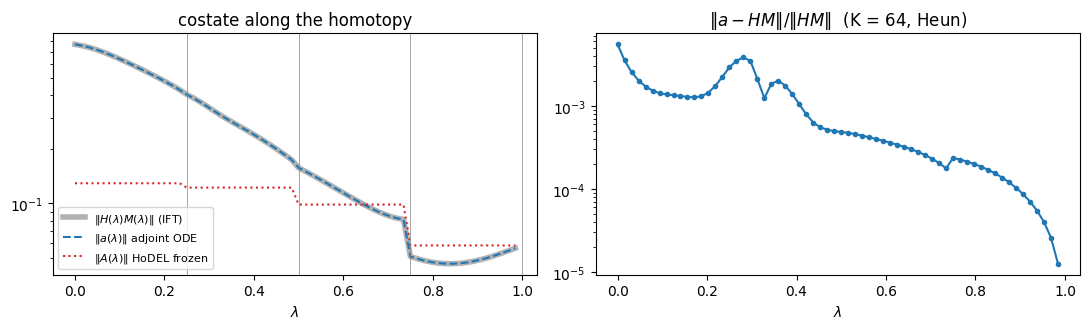

max relative deviation of the ODE adjoint from H(lam) M(lam): 5.51e-03


In [6]:
K = 64
lams, obs = grid(K)
rod_t = with_mlp(mlp_test)
_, _, a_path = eqx.filter_jit(adjoint_value_and_grad)(mlp_test, lams)
xs, auxs, _ = forward_states(rod_t, lams)
zs = jax.vmap(z_of)(lams)
Hs = jax.vmap(lambda x, z, a: rod_t.hessian(x, z, a)[0])(xs, zs, auxs)
dldx = jax.grad(obs_loss)(xs[obs])

mu = {int(k): jnp.linalg.solve(Hs[k], dldx[i]) for i, k in enumerate(obs)}
M = jnp.stack([sum((mu[j] for j in mu if j > k), jnp.zeros_like(xs[0])) for k in range(K)])  # M on (lam_k, lam_{k+1}]
A = jnp.stack([sum((dldx[i] for i, j in enumerate(obs) if j > k), jnp.zeros_like(xs[0])) for k in range(K)])
HM = jnp.einsum("kij,kj->ki", Hs[:K], M)

err = jnp.linalg.norm(a_path - HM, axis=1) / jnp.linalg.norm(HM, axis=1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(lams[:K], jnp.linalg.norm(HM, axis=1), "k", lw=4, alpha=.3, label=r"$\|H(\lambda)M(\lambda)\|$ (IFT)")
ax[0].plot(lams[:K], jnp.linalg.norm(a_path, axis=1), "C0--", label=r"$\|a(\lambda)\|$ adjoint ODE")
ax[0].plot(lams[:K], jnp.linalg.norm(A, axis=1), "C3:", label=r"$\|A(\lambda)\|$ HoDEL frozen")
for o in OBS: ax[0].axvline(o, color="gray", lw=.5)
ax[0].set_xlabel(r"$\lambda$"); ax[0].set_yscale("log"); ax[0].legend(fontsize=8); ax[0].set_title("costate along the homotopy")
ax[1].semilogy(lams[:K], err, "C0.-")
ax[1].set_xlabel(r"$\lambda$"); ax[1].set_title(r"$\|a - HM\| / \|HM\|$  (K = 64, Heun)")
plt.tight_layout(); plt.show()
print(f"max relative deviation of the ODE adjoint from H(lam) M(lam): {float(err.max()):.2e}")

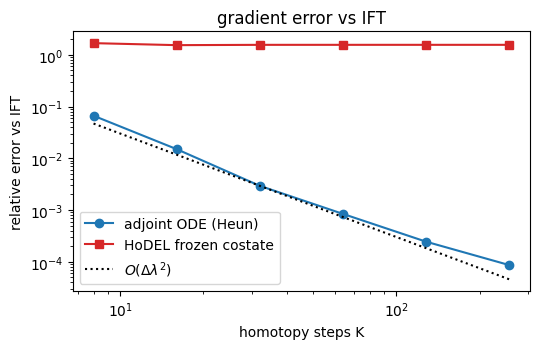

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.loglog(rows[:, 0], rows[:, 1], "C0o-", label="adjoint ODE (Heun)")
ax.loglog(rows[:, 0], rows[:, 2], "C3s-", label="HoDEL frozen costate")
ax.loglog(rows[:, 0], rows[2, 1] * (rows[2, 0] / rows[:, 0]) ** 2, "k:", label=r"$O(\Delta\lambda^2)$")
ax.set_xlabel("homotopy steps K"); ax.set_ylabel("relative error vs IFT"); ax.legend(); ax.set_title("gradient error vs IFT")
plt.tight_layout(); plt.show()

## 3. Speed on CPU

Both methods share the forward pass, i.e. the warm-started Newton solves of `rod.solve`. We time the forward pass alone, the IFT value and gradient, and the adjoint-ODE value and gradient. Every function is compiled before timing, and we report the median wall-clock of several runs. The adjoint ODE needs a fine $K$ to be accurate, while the IFT is exact at any $K$ (Section 2a). The fair comparison is therefore at matched accuracy, not at matched $K$.

In [8]:
def bench(fn, *args, n=5):
    jax.block_until_ready(fn(*args))  # compile
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


forward_only = eqx.filter_jit(lambda mlp, lams: forward_states(with_mlp(mlp), lams)[0])
timing = []
for K in [8, 16, 32, 64, 128, 256]:
    lams, _ = grid(K)
    t_fwd = bench(forward_only, mlp_test, lams)
    t_ift = bench(ift_value_and_grad, mlp_test, lams)
    t_ode = bench(adjoint_ode, mlp_test, lams)
    timing.append((K, t_fwd, t_ift, t_ode))
    print(f"K={K:4d}  forward {1e3 * t_fwd:7.1f} ms   IFT value+grad {1e3 * t_ift:7.1f} ms   "
          f"adjoint ODE value+grad {1e3 * t_ode:8.1f} ms   (ODE / IFT = {t_ode / t_ift:4.1f}x)")
timing = np.array(timing)

K=   8  forward    31.7 ms   IFT value+grad    36.6 ms   adjoint ODE value+grad     54.5 ms   (ODE / IFT =  1.5x)


K=  16  forward    57.3 ms   IFT value+grad    65.6 ms   adjoint ODE value+grad     99.7 ms   (ODE / IFT =  1.5x)


K=  32  forward    92.1 ms   IFT value+grad   117.3 ms   adjoint ODE value+grad    173.7 ms   (ODE / IFT =  1.5x)


K=  64  forward   152.2 ms   IFT value+grad   204.4 ms   adjoint ODE value+grad    292.7 ms   (ODE / IFT =  1.4x)


K= 128  forward   226.1 ms   IFT value+grad   331.0 ms   adjoint ODE value+grad    530.1 ms   (ODE / IFT =  1.6x)


K= 256  forward   465.3 ms   IFT value+grad   623.9 ms   adjoint ODE value+grad    992.9 ms   (ODE / IFT =  1.6x)


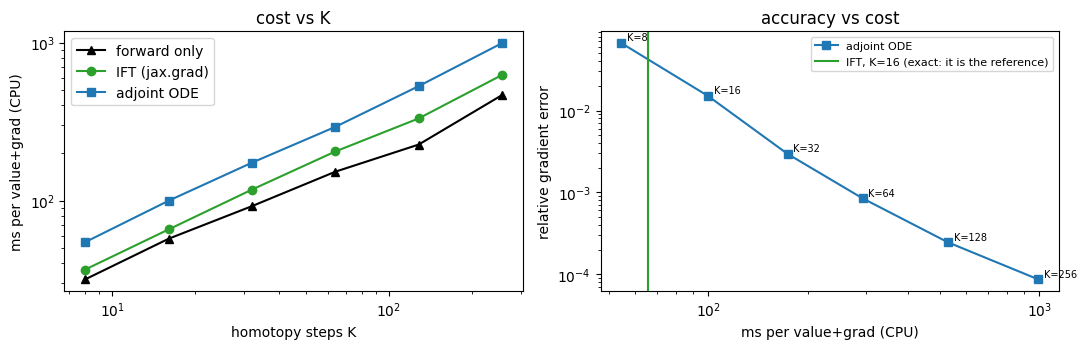

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].loglog(timing[:, 0], 1e3 * timing[:, 1], "k^-", label="forward only")
ax[0].loglog(timing[:, 0], 1e3 * timing[:, 2], "C2o-", label="IFT (jax.grad)")
ax[0].loglog(timing[:, 0], 1e3 * timing[:, 3], "C0s-", label="adjoint ODE")
ax[0].set_xlabel("homotopy steps K"); ax[0].set_ylabel("ms per value+grad (CPU)"); ax[0].legend(); ax[0].set_title("cost vs K")

ax[1].loglog(1e3 * timing[:, 3], rows[:, 1], "C0s-", label="adjoint ODE")
for K, e, t in zip(timing[:, 0], rows[:, 1], timing[:, 3]):
    ax[1].annotate(f"K={int(K)}", (1e3 * t, e), fontsize=7, textcoords="offset points", xytext=(4, 2))
ax[1].axvline(1e3 * timing[1, 2], color="C2", label="IFT, K=16 (exact: it is the reference)")
ax[1].set_xlabel("ms per value+grad (CPU)"); ax[1].set_ylabel("relative gradient error"); ax[1].legend(fontsize=8)
ax[1].set_title("accuracy vs cost")
plt.tight_layout(); plt.show()

## 4. Ablation: learning the bending law

We train the same MLP from the same initialization with Adam (same learning rate and number of updates), swapping only the gradient:

| run | gradient | K |
|---|---|---|
| IFT | `jax.grad` through `rod.solve` | 16 |
| adjoint ODE | Heun backward adjoint | 16 |
| adjoint ODE (fine) | Heun backward adjoint | 64 |
| HoDEL frozen | Eq. 24 as implemented (frozen costate) | 64 |

$K=16$ is enough for Newton continuation on this path.

In [10]:
def adam_step(params, grads, state, lr=2e-2, b1=0.9, b2=0.999):
    m, v, t = state; t += 1
    m = jax.tree.map(lambda a, g: b1 * a + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda a, g: b2 * a + (1 - b2) * g * g, v, grads)
    step = jax.tree.map(lambda a, b: lr * (a / (1 - b1 ** t)) / (jnp.sqrt(b / (1 - b2 ** t)) + 1e-8), m, v)
    return jax.tree.map(lambda p, s: p - s, params, step), (m, v, t)


def train(value_and_grad, K, iters=150):
    lams, _ = grid(K)
    params, static = eqx.partition(mlp0, eqx.is_inexact_array)
    state = (jax.tree.map(jnp.zeros_like, params), jax.tree.map(jnp.zeros_like, params), 0)
    jax.block_until_ready(value_and_grad(mlp0, lams))  # compile outside the timing
    hist, t0 = [], time.perf_counter()
    for it in range(iters):
        loss, g = value_and_grad(eqx.combine(params, static), lams)
        params, state = adam_step(params, eqx.filter(g, eqx.is_inexact_array), state)
        hist.append(float(loss))
    return eqx.combine(params, static), np.array(hist), time.perf_counter() - t0


runs = {
    "IFT (K=16)": (ift_value_and_grad, 16),
    "adjoint ODE (K=16)": (adjoint_ode, 16),
    "adjoint ODE (K=64)": (adjoint_ode, 64),
    "HoDEL frozen (K=64)": (hodel_frozen, 64),
}
results = {}
for name, (vg, K) in runs.items():
    mlp, hist, wall = train(vg, K)
    results[name] = (mlp, hist, wall)
    print(f"{name:22s} final loss {hist[-1]:.2e}   min loss {hist.min():.2e}   wall-clock {wall:6.1f} s "
          f"({1e3 * wall / len(hist):6.1f} ms/update)")

IFT (K=16)             final loss 2.50e-08   min loss 2.50e-08   wall-clock   10.8 s (  72.3 ms/update)


adjoint ODE (K=16)     final loss 3.45e-08   min loss 3.45e-08   wall-clock   13.7 s (  91.4 ms/update)


adjoint ODE (K=64)     final loss 2.48e-08   min loss 2.48e-08   wall-clock   44.5 s ( 296.7 ms/update)


HoDEL frozen (K=64)    final loss 4.68e-07   min loss 4.68e-07   wall-clock   34.6 s ( 230.7 ms/update)


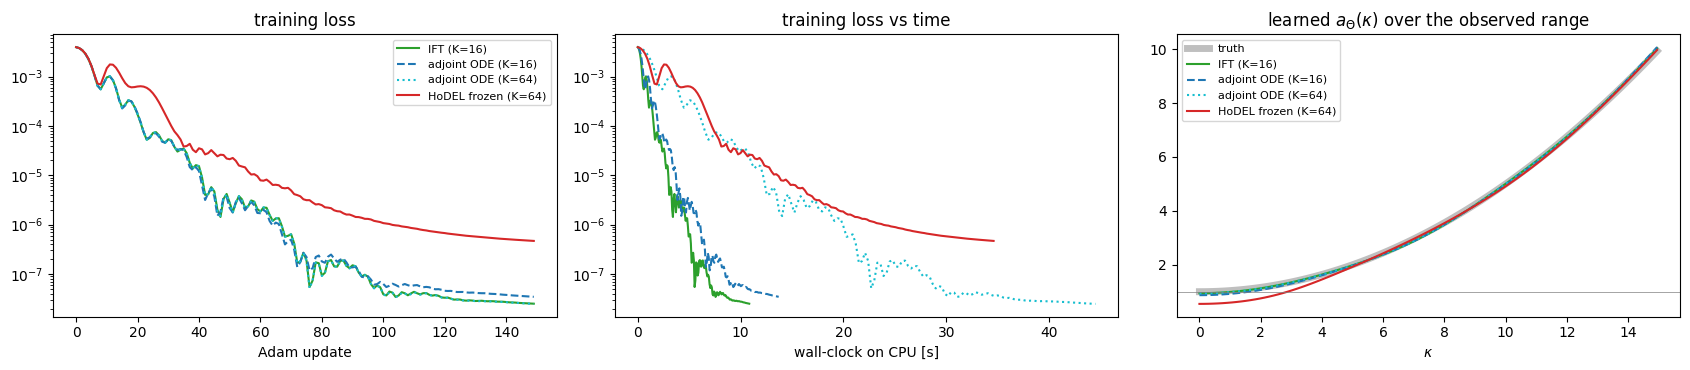

IFT (K=16)             max |a - a*| = 9.85e-02   weights relative distance to the IFT run = 0.0e+00
adjoint ODE (K=16)     max |a - a*| = 1.42e-01   weights relative distance to the IFT run = 8.7e-02
adjoint ODE (K=64)     max |a - a*| = 1.01e-01   weights relative distance to the IFT run = 6.3e-03
HoDEL frozen (K=64)    max |a - a*| = 4.52e-01   weights relative distance to the IFT run = 4.8e-01


In [11]:
colors = {"IFT (K=16)": "C2", "adjoint ODE (K=16)": "C0", "adjoint ODE (K=64)": "C9", "HoDEL frozen (K=64)": "C3"}
styles = {"IFT (K=16)": "-", "adjoint ODE (K=16)": "--", "adjoint ODE (K=64)": ":", "HoDEL frozen (K=64)": "-"}
fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
for name, (mlp, hist, wall) in results.items():
    ax[0].semilogy(hist, styles[name], color=colors[name], label=name)
    ax[1].semilogy(np.linspace(0, wall, len(hist)), hist, styles[name], color=colors[name], label=name)
ax[0].set_xlabel("Adam update"); ax[0].set_title("training loss"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("wall-clock on CPU [s]"); ax[1].set_title("training loss vs time")

kk = jnp.linspace(0, kmax, 100)
ax[2].plot(kk, 1 + (kk / KAPPA0) ** 2, "k", lw=5, alpha=.25, label="truth")
for name, (mlp, hist, wall) in results.items():
    a = jax.vmap(with_mlp(mlp).terms[0].model.a)(kk)
    ax[2].plot(kk, a, styles[name], color=colors[name], label=name)
ax[2].axhline(1.0, color="gray", lw=.5)
ax[2].set_xlabel(r"$\kappa$"); ax[2].set_title(r"learned $a_\Theta(\kappa)$ over the observed range"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

ref = flat(results["IFT (K=16)"][0])
for name, (mlp, hist, wall) in results.items():
    a_err = float(jnp.max(jnp.abs(jax.vmap(with_mlp(mlp).terms[0].model.a)(kk) - (1 + (kk / KAPPA0) ** 2))))
    dist = float(jnp.linalg.norm(flat(mlp) - ref) / jnp.linalg.norm(ref))
    print(f"{name:22s} max |a - a*| = {a_err:.2e}   weights relative distance to the IFT run = {dist:.1e}")

## Takeaways

* **Equivalence.** On the equilibrium manifold the HoDEL adjoint ODE and the IFT give the same gradient: $a(\lambda)=H(\lambda)\sum_{\lambda_i>\lambda}\mu_i$ and the $\lambda$ integral telescopes to $-\sum_i\mu_i^\top g_{\Theta,i}$. Numerically, the Heun adjoint converges to the `jax.grad` gradient: the relative error is $6.7\times10^{-2}$ at $K=8$ and $8.7\times10^{-5}$ at $K=256$. That is about 2nd order at first, flattening slightly at large $K$, where the per-step frozen frame `aux` and the Newton tolerance start to matter. The costate tracks $H(\lambda)M(\lambda)$ to within $0.6\%$ at $K=64$. In the ablation, the IFT run and the adjoint-ODE runs follow the same training trajectory.
* **The IFT is the closed form of the adjoint ODE.** It has no discretization error, no third derivatives, no backward integration, and no stiffness restriction on $\Delta\lambda$ (Theorem 3). On CPU, at equal $K$ the adjoint ODE costs about $1.5\times$ the IFT value and gradient. At equal accuracy the gap is larger: the IFT is exact at $K=16$ (73 ms/update), while the adjoint ODE needs $K\ge64$ for $<10^{-3}$ error (300 ms/update), about $4\times$ slower.
* **The frozen costate is a different gradient.** Contracting $\partial_\Theta f$ with $A(\lambda)=\sum\nabla\ell_i$ (Eq. 24 as implemented) drops the $f_xs$ term. Here it is off by about $150\%$ (cosine $\approx0.92$) at every $K$. It still descends, but it converges to a worse fit ($\sim20\times$ higher loss) with a visibly wrong $a(\kappa)$ at small $\kappa$. It is exact only for energies quadratic in $x$, like the paper's scalar example.
* **Memory.** Both approaches store only the equilibrium states, not the Newton iterations: `custom_root` does not trace the solver, which gives the paper's memory argument for free.